# Reconstruction de l'environnement à l'aide d'un CNN à partir des signaux reçus

## Données

C'est un fichier .mat avec un champ "data" qui contient une matrice de 41 * 2001 signaux et un champ "map" qui contient l'état réel de la carte

Le code fait un apprentissage basique à développer plus


# 1) Imports

In [1]:
import numpy as np
from scipy.io import loadmat
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import random
import copy
import os
from scipy.ndimage import binary_erosion, binary_dilation


# 2) Charger les données

In [2]:
DATA_FILES = [
    ('3Rond',              'NOUVEAU_8capteurs_300samples_3_rond.mat', 1500)
]
SIGNAL_START = DATA_FILES[0][2]   # on ignore la partie aller (émission)
DATA_PATH = DATA_FILES[0][1]
if not os.path.exists(DATA_PATH):
    print(f"Erreur : fichier '{DATA_PATH}' introuvable.")
else:
    raw_data = loadmat(DATA_PATH)["results"].squeeze()

    list_experiments = []
    for exp in raw_data:
        # Ignorer les entrées vides (première ligne du struct MATLAB)
        if np.array(exp['data']).size > 0:
            list_experiments.append(exp)

    print(f"Échantillons valides : {len(list_experiments)}")

Échantillons valides : 300


# 3) Séparer les inputs et les outputs

On garde seulement à partir de la 1200 ème colonne les signaux pour limiter la taille et ne pas compter le trajet aller.

Pour la matrice de sortie comme c'est majoritairement des 0 on ne garde que l'espace où se trouve la demi sphère.

In [3]:
list_signals = []
list_outputs = []

for exp in list_experiments:
    signals         = np.array(exp['data']).squeeze()   # (9, 2001)
    visible_section = np.array(exp['visible_section']).squeeze()   # (150, 150)

    list_signals.append(signals[:, SIGNAL_START:])   # (9, 801)
    list_outputs.append(visible_section)             # (150, 150) — cible : zone visible

X = np.array(list_signals, dtype=np.float32)   # (N, 9, 801)
y = np.array(list_outputs, dtype=np.float32)   # (N, 150, 150)

print(f"Shape X (signaux) : {X.shape}")
print(f"Shape y (visible) : {y.shape}")
ratio_pos = y.mean()
print(f"Ratio pixels positifs (visible_section) : {ratio_pos*100:.2f}%")


Shape X (signaux) : (300, 8, 2056)
Shape y (visible) : (300, 150, 150)
Ratio pixels positifs (visible_section) : 0.11%


# 4) Normalisation

Il est necessaire de normaliser les données pour l'apprentissage

In [4]:
# Normalisation par capteur : moyenne/std calculées sur l'axe temps+samples
# Shape X : (N, 9, 801) → mean/std sur axes (0, 2) → (1, 9, 1)
mean_per_ch = X.mean(axis=(0, 2), keepdims=True)
std_per_ch  = X.std(axis=(0, 2),  keepdims=True)
std_per_ch[std_per_ch == 0] = 1.0

X_normalized = (X - mean_per_ch) / std_per_ch
print(f"Après normalisation — mean: {X_normalized.mean():.4f}, std: {X_normalized.std():.4f}")


Après normalisation — mean: 0.0000, std: 1.0000


# 5) Visualisation des données

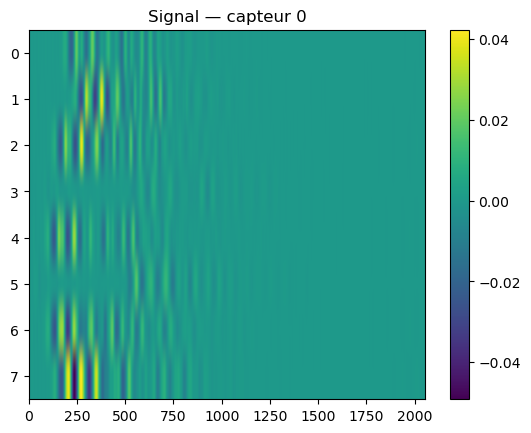

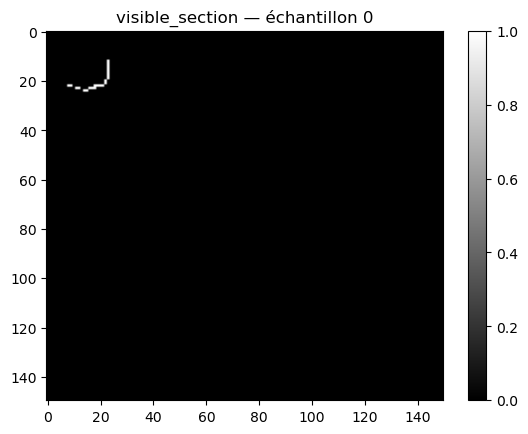

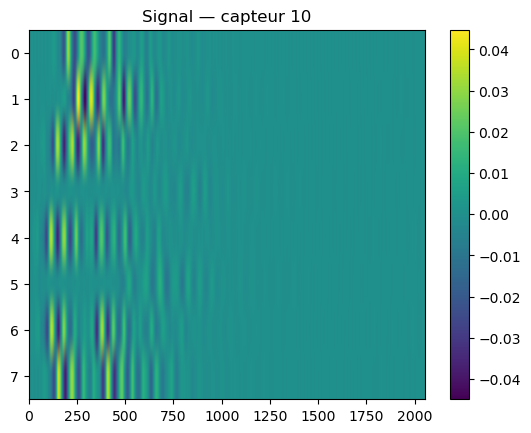

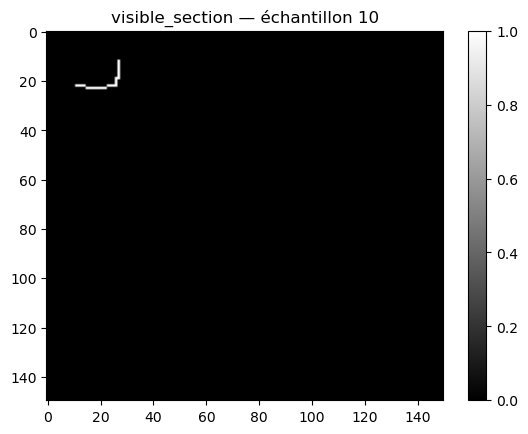

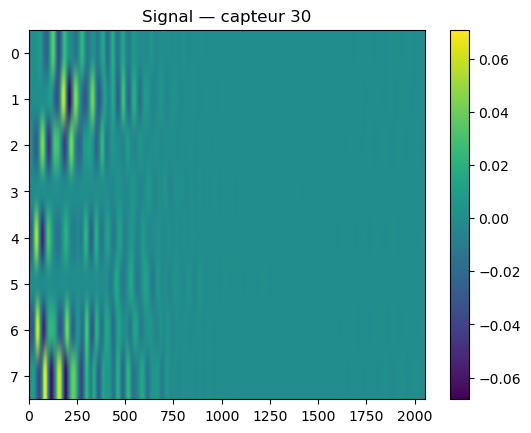

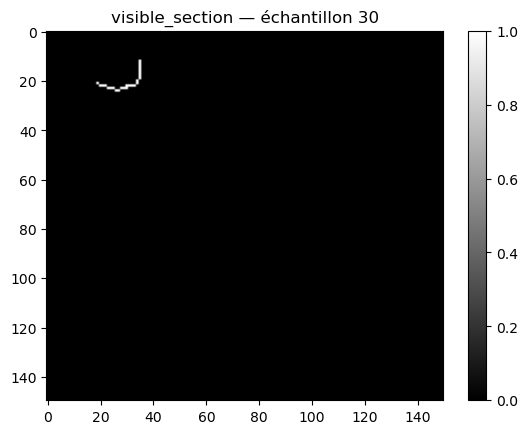

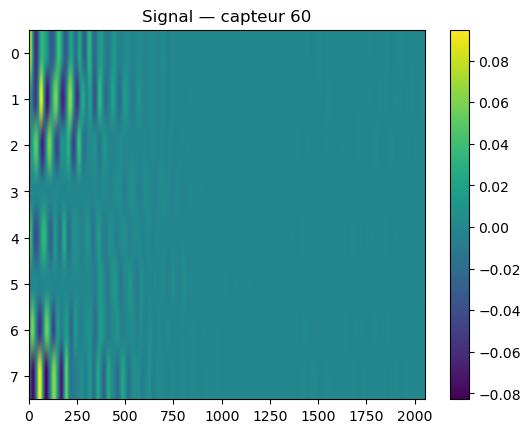

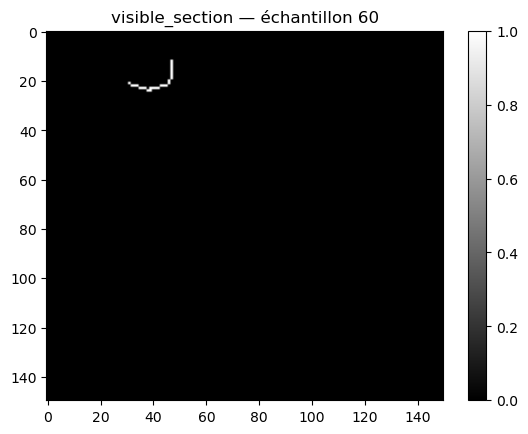

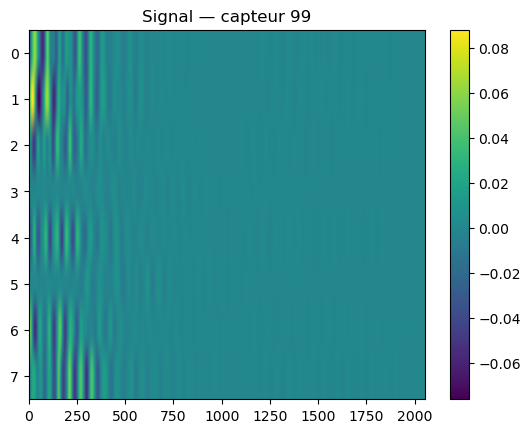

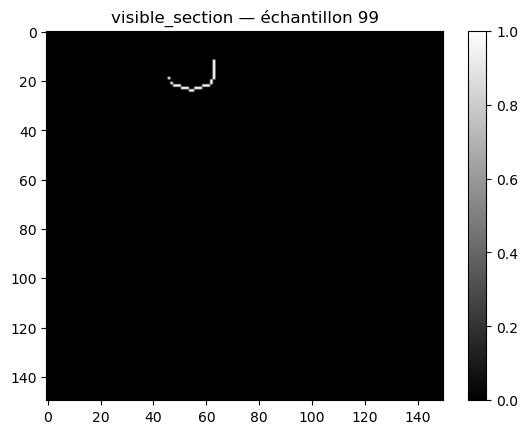

In [5]:
indices = [0, 10, 30, 60, 99]
for idx in indices:
    plt.imshow(X[idx], aspect='auto')
    plt.colorbar()
    plt.title(f"Signal — capteur {idx}")
    plt.show()

    plt.imshow(y[idx], cmap='gray', aspect='auto')
    plt.colorbar()
    plt.title(f"visible_section — échantillon {idx}")
    plt.show()


## (Optionnel) Associer les signaux pour pas qu'il y ai t de conflit avec le code de Maxime

In [6]:
X = X_normalized

# 6) Dataset personalisé

In [7]:
class SignalToImageDataset(Dataset):
    def __init__(self, X, y, augment=False):
        X = np.array(X, dtype=np.float32)  # (N, 9, 801)
        y = np.array(y, dtype=np.float32)  # (N, 150, 150)

        self.X = torch.tensor(X).unsqueeze(1)  # (N, 1, 9, 801)
        self.y = torch.tensor(y).unsqueeze(1)  # (N, 1, 150, 150)
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        y = self.y[idx]

        if self.augment:
            # Bruit gaussien (σ = 1% de l'amplitude normalisée)
            if random.random() > 0.5:
                x = x + torch.randn_like(x) * 0.01

            # Décalage temporel circulaire (±10 samples)
            if random.random() > 0.5:
                shift = random.randint(-10, 10)
                x = torch.roll(x, shift, dims=-1)

            # Flip horizontal (symétrie du réseau de capteurs — physiquement valide)
            if random.random() > 0.5:
                x = torch.flip(x, dims=[-2])  # flip sur l'axe capteurs
                y = torch.flip(y, dims=[-1])  # flip correspondant sur la carte

            # Scaling d'amplitude
            if random.random() > 0.5:
                x = x * random.uniform(0.8, 1.2)

            # Écho artificiel (retard + atténuation)
            if random.random() > 0.7:
                delay = random.randint(5, 20)
                x = x + torch.roll(x, delay, dims=-1) * 0.15

        return x, y

In [8]:
BATCH_SIZE = 8

# 7) Modèle CNN

In [9]:
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        
        # ----- Encodeur -----
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),  # ↓

            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),  # ↓

            nn.Conv2d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2)   # ↓
        )
        
        # Taille après encodeur (calcul dynamique)
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 41, 2001)
            out = self.encoder(dummy)
            enc_h, enc_w = out.shape[2], out.shape[3]

        # ----- Décodeur -----
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 8, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.Conv2d(8, 1, kernel_size=3, padding=1),
            # Pas de Sigmoid ici — le modèle retourne des logits (BCEWithLogitsLoss)
        )

        # Taille de sortie cible
        self.output_size = (150, 150)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        # Interpolation bilinéaire vers la taille cible (plus propre que le crop brutal)
        return F.interpolate(x, size=self.output_size, mode='bilinear', align_corners=False)
    
def pixel_accuracy(outputs, targets, threshold=0.5):
    """
    Calcule l'accuracy pixel par pixel.
    outputs : logits — sigmoid appliqué en interne
    targets : (N, 2250) -> 0 ou 1
    """
    outputs = torch.sigmoid(outputs)
    preds = (outputs >= threshold).float()
    correct = (preds == targets).float().sum()
    total = targets.numel()
    return (correct / total).item()

def show_test_predictions(model, test_loader, device, num_samples=3, threshold=0.5):
    """
    Affiche num_samples prédictions du test set, reshaped en (15,150).
    """
    model.eval()
    shown = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = torch.sigmoid(model(inputs))
            
            # Binarisation selon le seuil
            preds = (outputs >= threshold).float()
            preds=outputs

            for i in range(inputs.size(0)):
                pred_img = preds[i].squeeze().cpu().numpy()
                target_img = targets[i].squeeze().cpu().numpy()

                fig, axes = plt.subplots(1, 2, figsize=(8, 4))
                axes[0].imshow(target_img, cmap="gray")
                axes[0].set_title("Vérité terrain")
                axes[0].axis("off")

                axes[1].imshow(pred_img, cmap="gray")
                axes[1].set_title("Prédiction")
                axes[1].axis("off")

                plt.show()

                shown += 1
                if shown >= num_samples:
                    return

# 7b) Fonction de perte : BCE + Dice Loss

La **Dice Loss** mesure le chevauchement entre la prédiction et la vérité terrain.
Elle est particulièrement adaptée aux données déséquilibrées et force le modèle à bien reconstruire la **forme** complète de l'objet, pas seulement sa position.

`Loss = BCE + Dice`

# 7c) Architecture U-Net avec skip connections

Le U-Net relie chaque niveau de l'encodeur directement au décodeur correspondant via des **skip connections**.
Cela permet de préserver les détails spatiaux fins (forme, contours) qui sont perdus dans le goulot d'étranglement du CNN simple.

Chaque bloc inclut aussi une **BatchNorm** pour stabiliser l'entraînement.

In [10]:
class DoubleConv(nn.Module):
    """Deux convolutions consécutives avec BatchNorm, ReLU et Dropout optionnel."""
    def __init__(self, in_ch, out_ch, dropout_p=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout_p > 0:
            layers.append(nn.Dropout2d(dropout_p))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class UNet(nn.Module):
    def __init__(self, dropout_p=0.1):
        super().__init__()
        # Encodeur (avec dropout pour régularisation sur petit dataset)
        self.enc1 = DoubleConv(1, 32, dropout_p=dropout_p)
        self.enc2 = DoubleConv(32, 64, dropout_p=dropout_p)
        self.enc3 = DoubleConv(64, 128, dropout_p=dropout_p)
        self.pool = nn.MaxPool2d(2)

        # Goulot d'étranglement (dropout pour régulariser la représentation la plus compressée)
        self.bottleneck = DoubleConv(128, 256, dropout_p=0.2)

        # Décodeur (sans dropout)
        self.up3  = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(256, 128)   # 128 (up) + 128 (skip)

        self.up2  = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)    # 64  (up) + 64  (skip)

        self.up1  = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(64, 32)     # 32  (up) + 32  (skip)

        self.final   = nn.Conv2d(32, 1, kernel_size=1)
        self.output_size = (150, 150)

    def _crop(self, skip, target):
        """Recadre le skip pour correspondre à la taille de target."""
        _, _, h, w = target.shape
        return skip[:, :, :h, :w]

    def forward(self, x):
        # Encodeur + skip connections
        s1 = self.enc1(x)                    # (32, 41, 801)
        s2 = self.enc2(self.pool(s1))        # (64, 20, 400)
        s3 = self.enc3(self.pool(s2))        # (128, 10, 200)

        # Goulot
        b = self.bottleneck(self.pool(s3))   # (256, 5, 100)

        # Décodeur avec skip connections
        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, self._crop(s3, d3)], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, self._crop(s2, d2)], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, self._crop(s1, d1)], dim=1))

        out = self.final(d1)  # logits — pas de Sigmoid

        # Interpolation bilinéaire vers la taille cible
        return F.interpolate(out, size=self.output_size, mode='bilinear', align_corners=False)

In [11]:
class FocalDiceLoss(nn.Module):
    """
    Focal Loss + Dice Loss — conçu pour les classes très déséquilibrées (< 1% positifs).

    Focal Loss : down-pondère les exemples faciles (pixels à 0 bien classés) via (1-p_t)^γ,
    forçant le réseau à se concentrer sur les positifs difficiles.
    alpha pondère les positifs (> 0.5 recommandé si très peu de positifs).

    Les modèles retournent des logits — pas de Sigmoid en sortie.
    """
    def __init__(self, alpha=0.75, gamma=2.0, dice_weight=0.5):
        super().__init__()
        self.alpha       = alpha        # poids des positifs (0 < alpha < 1)
        self.gamma       = gamma        # facteur de focalisation (2 = standard)
        self.dice_weight = dice_weight  # part de la Dice dans la loss totale

    def forward(self, logits, targets):
        # ── Focal Loss ───────────────────────────────────────────────────────
        bce     = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t     = torch.exp(-bce)
        # alpha_t : alpha pour les positifs, (1-alpha) pour les négatifs
        alpha_t    = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_loss = (alpha_t * (1 - p_t) ** self.gamma * bce).mean()

        # ── Dice Loss (sur probabilités) ─────────────────────────────────────
        probs  = torch.sigmoid(logits)
        smooth = 1e-6
        p_flat = probs.reshape(probs.size(0), -1)
        t_flat = targets.reshape(targets.size(0), -1)
        inter  = (p_flat * t_flat).sum(dim=1)
        dice_loss = (1 - (2 * inter + smooth) / (p_flat.sum(dim=1) + t_flat.sum(dim=1) + smooth)).mean()

        return (1 - self.dice_weight) * focal_loss + self.dice_weight * dice_loss


# 8) Fonction d'entrainement avec découpage

In [12]:
def train_and_validate(X, y, model_class, epochs=200, batch_size=8, lr=5e-4, patience=30):
    # Garantir que X et y sont des numpy arrays (résiste à y = list_outputs)
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    torch.manual_seed(42)
    random.seed(42)
    np.random.seed(42)

    # Dataset de base (sans augmentation) pour val/test
    full_dataset = SignalToImageDataset(X, y, augment=False)
    # Split 65/15/20 adapté aux ~380 échantillons disponibles
    n = len(full_dataset)
    n_train = int(0.65 * n)
    n_val   = int(0.15 * n)
    n_test  = n - n_train - n_val
    lengths = [n_train, n_val, n_test]
    train_set, val_set, test_set = random_split(full_dataset, lengths)

    # Dataset d'entraînement avec augmentation
    train_dataset_aug = SignalToImageDataset(
        X[list(train_set.indices)],
        y[list(train_set.indices)],
        augment=True
    )

    train_loader = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_set,  batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_set, batch_size=batch_size, shuffle=False)

    model = model_class()
    #device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    device = torch.device("cpu")
    model.to(device)

    criterion = FocalDiceLoss(alpha=0.75, gamma=2.0, dice_weight=0.5)
    # weight_decay=1e-4 pour régularisation L2
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    # Scheduler : divise le LR par 2 si la val_loss stagne pendant 10 epochs
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10, min_lr=1e-6
    )

    # Early stopping vars
    best_val_loss = float("inf")
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [],  "val_acc": [],
        "lr": []
    }

    for epoch in range(epochs):
        # ---- Train ----
        model.train()
        train_loss_sum = 0.0
        train_acc_sum  = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss_sum += loss.item()
            train_acc_sum  += pixel_accuracy(outputs, targets)

        # ---- Validation ----
        model.eval()
        val_loss_sum = 0.0
        val_acc_sum  = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss_sum += loss.item()
                val_acc_sum  += pixel_accuracy(outputs, targets)

        train_loss = train_loss_sum / len(train_loader)
        train_acc  = train_acc_sum  / len(train_loader)
        val_loss   = val_loss_sum   / len(val_loader)
        val_acc    = val_acc_sum    / len(val_loader)
        current_lr = optimizer.param_groups[0]['lr']

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        # Mise à jour du scheduler
        scheduler.step(val_loss)

        print(f"Epoch {epoch+1}/{epochs} "
              f"| Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} "
              f"| Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} "
              f"| LR: {current_lr:.2e}")

        # ---- Early stopping ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping à l'epoch {epoch+1}")
                break

    # ---- Restore best model ----
    model.load_state_dict(best_model_wts)

    # ---- Test set evaluation ----
    model.eval()
    test_loss_sum = 0.0
    test_acc_sum  = 0.0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss_sum += loss.item()
            test_acc_sum  += pixel_accuracy(outputs, targets)

    test_loss = test_loss_sum / len(test_loader)
    test_acc  = test_acc_sum  / len(test_loader)
    print(f"\nTest Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

    # ---- Courbes ----
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"],   label="Val Loss")
    axes[0].axhline(y=test_loss, color='r', linestyle='--', label=f"Test Loss ({test_loss:.4f})")
    axes[0].set_xlabel("Epochs"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].set_title("Loss vs Epochs")

    axes[1].plot(history["train_acc"], label="Train Acc")
    axes[1].plot(history["val_acc"],   label="Val Acc")
    axes[1].axhline(y=test_acc, color='r', linestyle='--', label=f"Test Acc ({test_acc:.4f})")
    axes[1].set_xlabel("Epochs"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(); axes[1].set_title("Accuracy vs Epochs")

    axes[2].plot(history["lr"])
    axes[2].set_xlabel("Epochs"); axes[2].set_ylabel("Learning Rate")
    axes[2].set_yscale("log"); axes[2].set_title("Learning Rate (scheduler)")

    plt.tight_layout()
    plt.show()

    # ---- Sauvegarde ----
    torch.save(model.state_dict(), "model_unet_finale.pth")
    print("Modèle sauvegardé dans model_unet_finale.pth")

    return model, train_loader, val_loader, test_loader

# 9) Lancement de l'entrainement

Epoch 1/200 | Train Loss: 0.5043 Acc: 0.9942 | Val Loss: 0.5015 Acc: 0.9989 | LR: 5.00e-04
Epoch 2/200 | Train Loss: 0.5003 Acc: 0.9989 | Val Loss: 0.4998 Acc: 0.9989 | LR: 5.00e-04
Epoch 3/200 | Train Loss: 0.4993 Acc: 0.9989 | Val Loss: 0.4992 Acc: 0.9988 | LR: 5.00e-04
Epoch 4/200 | Train Loss: 0.4986 Acc: 0.9988 | Val Loss: 0.4982 Acc: 0.9989 | LR: 5.00e-04
Epoch 5/200 | Train Loss: 0.4979 Acc: 0.9983 | Val Loss: 0.4978 Acc: 0.9960 | LR: 5.00e-04
Epoch 6/200 | Train Loss: 0.4971 Acc: 0.9974 | Val Loss: 0.4966 Acc: 0.9986 | LR: 5.00e-04
Epoch 7/200 | Train Loss: 0.4959 Acc: 0.9963 | Val Loss: 0.4959 Acc: 0.9872 | LR: 5.00e-04
Epoch 8/200 | Train Loss: 0.4950 Acc: 0.9958 | Val Loss: 0.4951 Acc: 0.9923 | LR: 5.00e-04
Epoch 9/200 | Train Loss: 0.4941 Acc: 0.9943 | Val Loss: 0.4940 Acc: 0.9954 | LR: 5.00e-04
Epoch 10/200 | Train Loss: 0.4927 Acc: 0.9936 | Val Loss: 0.4922 Acc: 0.9967 | LR: 5.00e-04
Epoch 11/200 | Train Loss: 0.4919 Acc: 0.9936 | Val Loss: 0.4919 Acc: 0.9967 | LR: 5.00e-

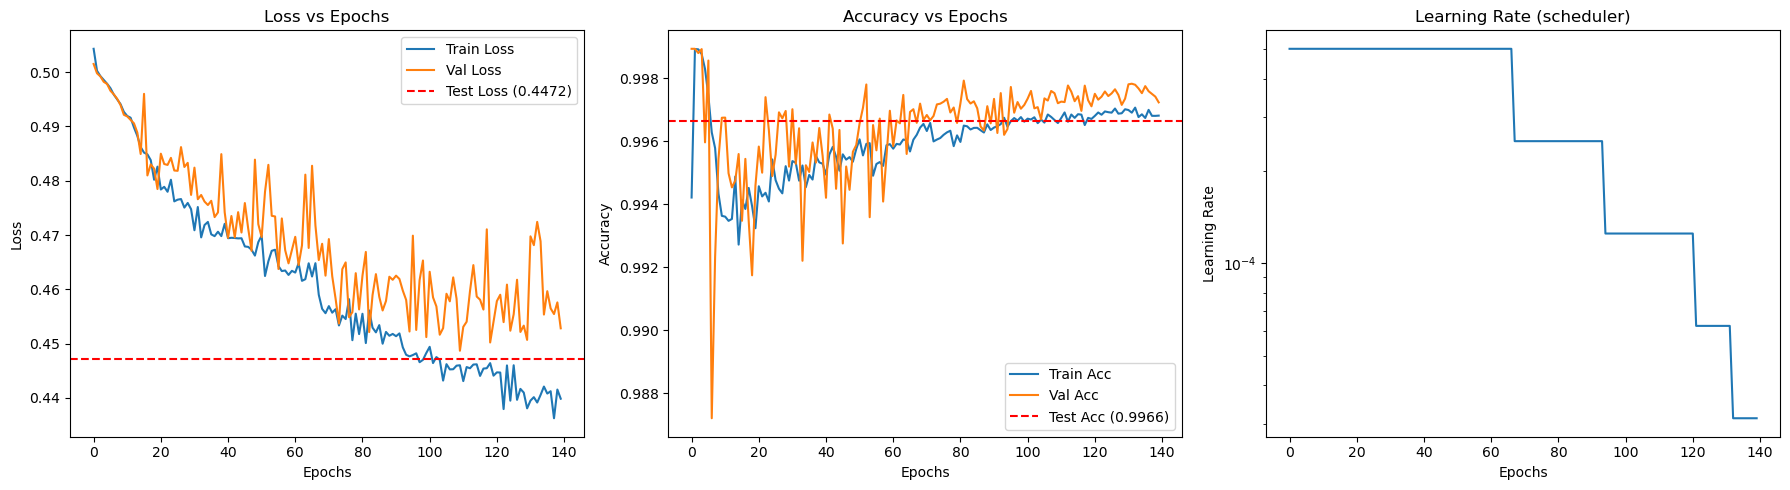

Modèle sauvegardé dans model_unet_finale.pth


In [14]:
model, train_loader, val_loader, test_loader = train_and_validate(X, y, UNet, batch_size=2)

# 9b) Recharger le modèle sans réentraîner

Exécuter cette cellule si le modèle a déjà été entraîné et sauvegardé (`model_cnn.pth` existe).

In [14]:
if os.path.exists("model_unet_finale.pth"):
    device = torch.device("cpu")

    model = UNet().to(device)
    model.load_state_dict(torch.load("model_unet_finale.pth", map_location=device))
    model.eval()

    # Recréer les dataloaders pour la visualisation
    dataset = SignalToImageDataset(X, y)
    torch.manual_seed(42)
    random.seed(42)
    np.random.seed(42)
    n = len(dataset)
    n_train = int(0.65 * n)
    n_val   = int(0.15 * n)
    n_test  = n - n_train - n_val
    train_set, val_set, test_set = random_split(dataset, [n_train, n_val, n_test])
    train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
    val_loader   = DataLoader(val_set,   batch_size=8, shuffle=False)
    test_loader  = DataLoader(test_set,  batch_size=8, shuffle=False)

    print("Modèle chargé depuis model_cnn.pth")
else:
    print("⚠️ Aucun fichier model_cnn.pth trouvé. Lance d'abord la cellule d'entraînement (section 9).")

Modèle chargé depuis model_cnn.pth


In [15]:
def load_model(model_class, path, device):
    model = model_class().to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    print(f"Modèle chargé depuis {path}")
    return model

# Décommenter si besoin :
#model_cnn  = load_model(SimpleCNN, "model_simplecnn.pth", device)
model_unet = load_model(UNet,   "model_unet_finale.pth",      device)

Modèle chargé depuis model_unet_finale.pth


# 10) Présentation des résultats

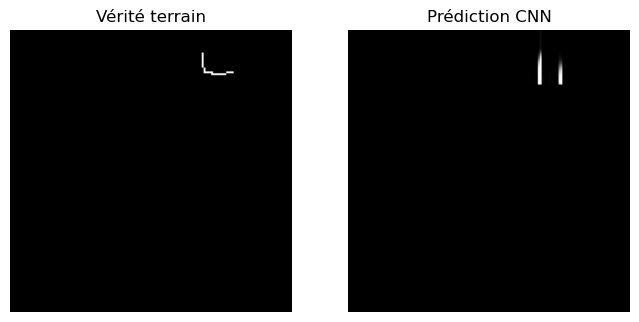

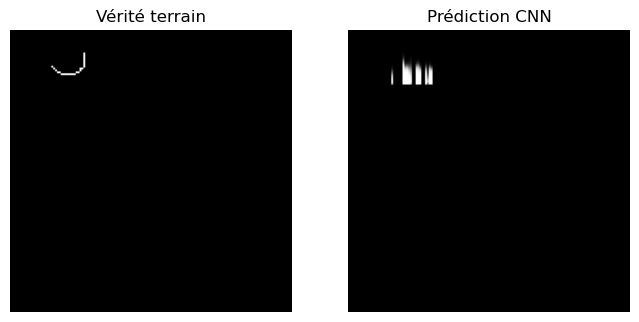

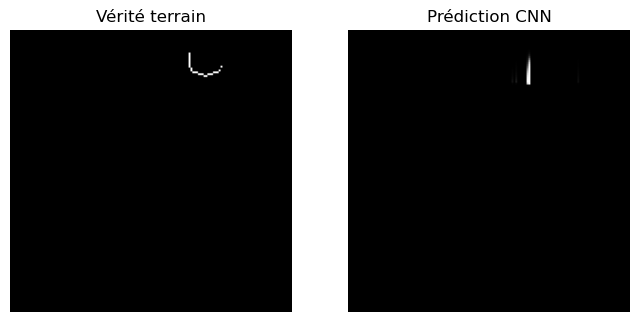

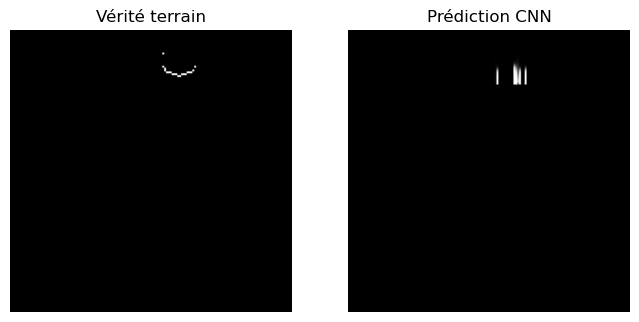

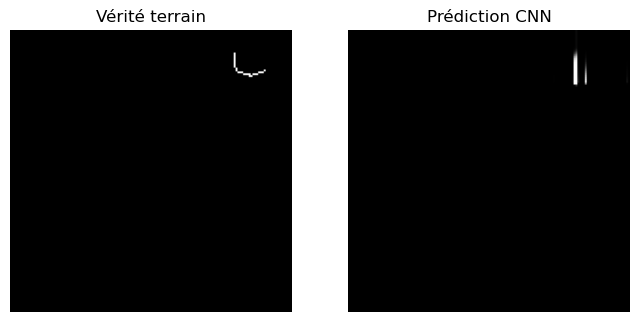

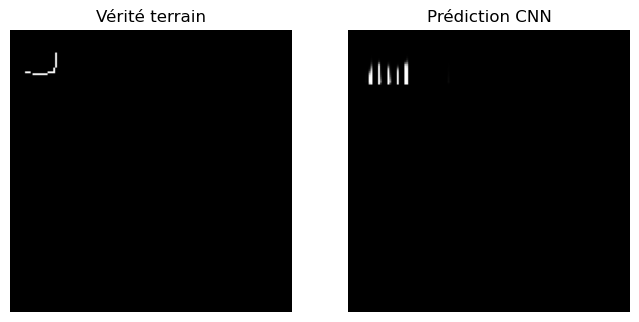

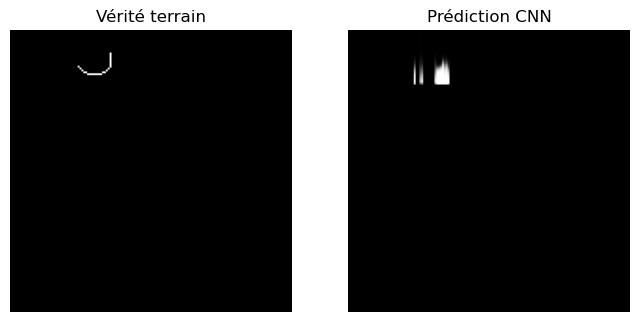

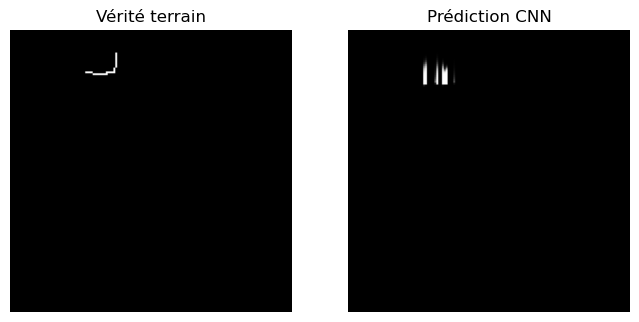

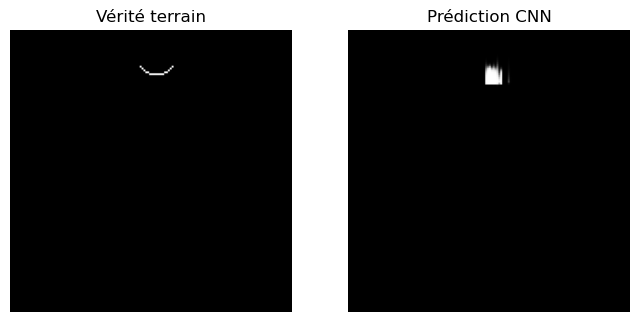

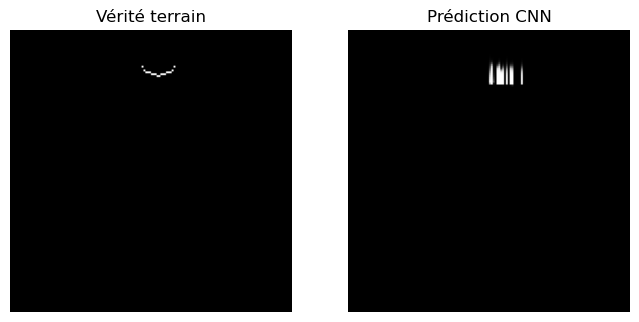

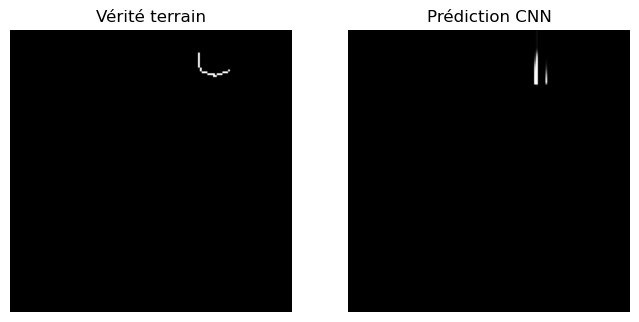

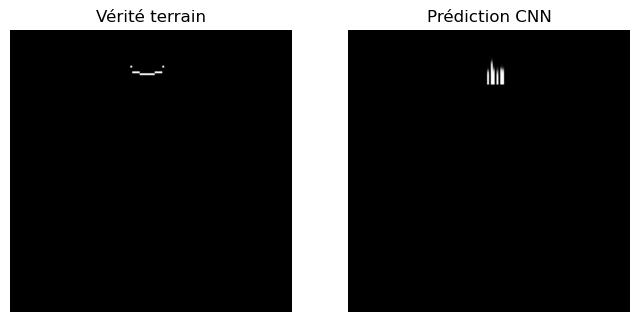

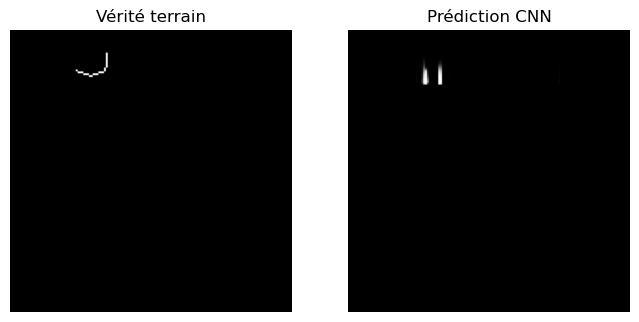

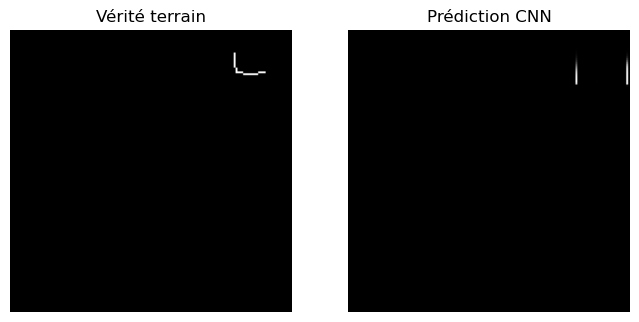

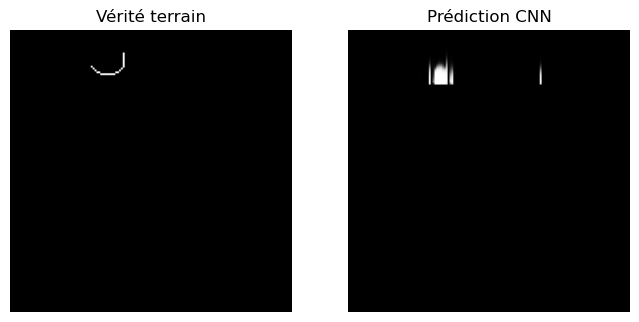

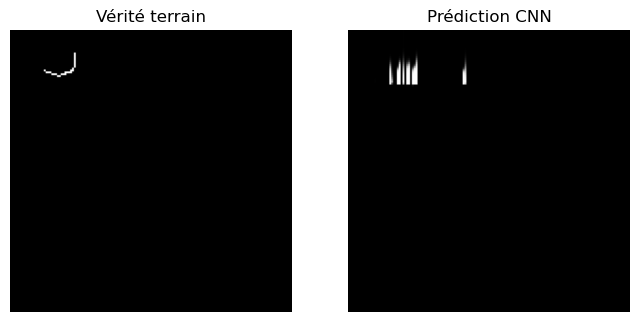

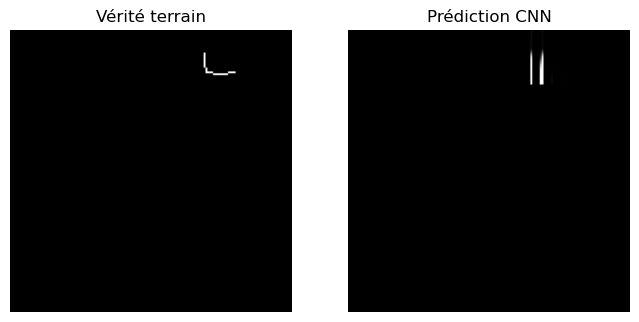

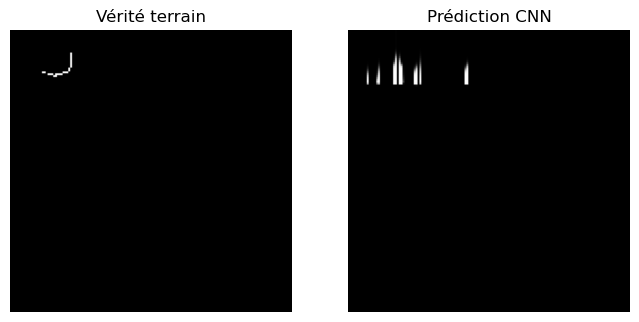

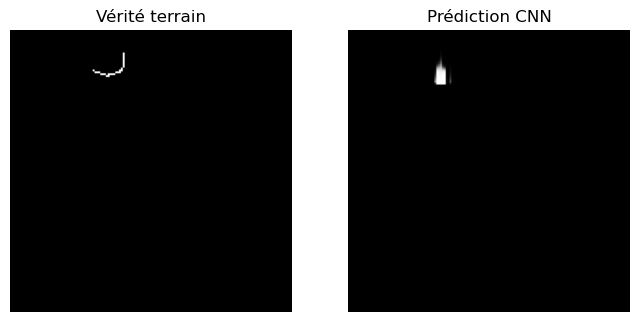

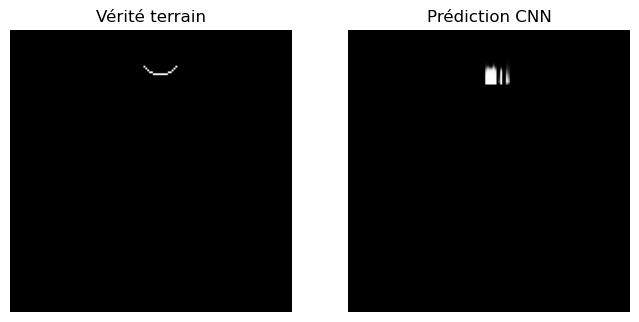

In [16]:
def show_predictions(model, loader, device, num_samples=3):
    model.eval()
    shown = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = torch.sigmoid(model(inputs))
            preds = outputs.cpu().numpy()

            for i in range(inputs.size(0)):
                fig, axes = plt.subplots(1, 2, figsize=(8, 4))
                axes[0].imshow(targets[i].cpu().squeeze(), cmap="gray")
                axes[0].set_title("Vérité terrain")
                axes[0].axis("off")

                axes[1].imshow(preds[i].squeeze(), cmap="gray")
                axes[1].set_title("Prédiction CNN")
                axes[1].axis("off")
                plt.show()

                shown += 1
                if shown >= num_samples:
                    return
                
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
show_predictions(model, test_loader, device, num_samples=20)

# 11) Diagnostic des prédictions

## 11a) Distribution des valeurs prédites

Vérifie si le modèle prédit des valeurs variées ou s'effondre vers 0 ou 1.

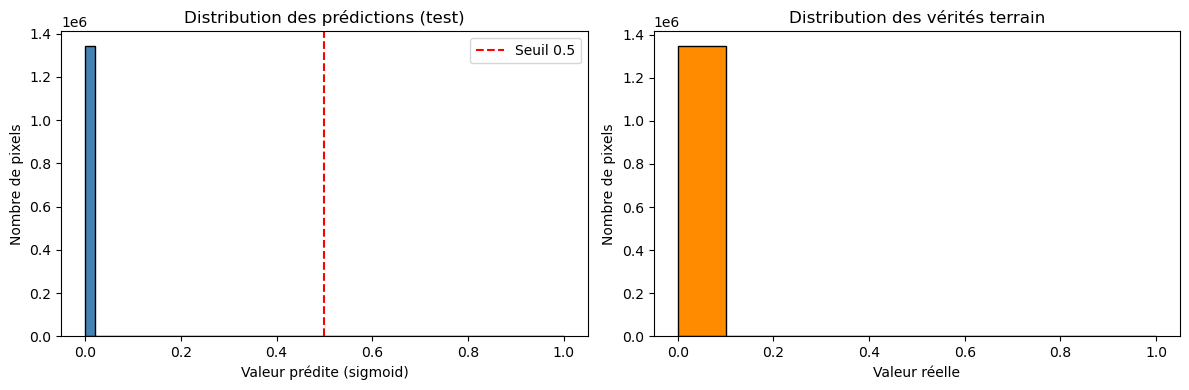

Ratio de pixels positifs (=1) dans la vérité terrain : 0.0011 (0.11%)
Moyenne des prédictions (test) : 0.0029
Std des prédictions (test)     : 0.0493


In [17]:
device = torch.device("cpu")

# --- Collecte sur le VAL set (pour calibrer le seuil sans biais) ---
val_preds_all   = []
val_targets_all = []

model.eval()
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = torch.sigmoid(model(inputs))
        val_preds_all.append(outputs.cpu().numpy().flatten())
        val_targets_all.append(targets.cpu().numpy().flatten())

val_preds_all   = np.concatenate(val_preds_all)
val_targets_all = np.concatenate(val_targets_all)

# --- Collecte sur le TEST set (pour évaluation finale uniquement) ---
all_preds   = []
all_targets = []

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = torch.sigmoid(model(inputs))
        all_preds.append(outputs.cpu().numpy().flatten())
        all_targets.append(targets.cpu().numpy().flatten())

all_preds   = np.concatenate(all_preds)
all_targets = np.concatenate(all_targets)

# Histogramme des valeurs prédites (test)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(all_preds, bins=50, color='steelblue', edgecolor='black')
plt.xlabel("Valeur prédite (sigmoid)")
plt.ylabel("Nombre de pixels")
plt.title("Distribution des prédictions (test)")
plt.axvline(x=0.5, color='red', linestyle='--', label="Seuil 0.5")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(all_targets, bins=10, color='darkorange', edgecolor='black')
plt.xlabel("Valeur réelle")
plt.ylabel("Nombre de pixels")
plt.title("Distribution des vérités terrain")

plt.tight_layout()
plt.show()

ratio_positifs = all_targets.mean()
print(f"Ratio de pixels positifs (=1) dans la vérité terrain : {ratio_positifs:.4f} ({ratio_positifs*100:.2f}%)")
print(f"Moyenne des prédictions (test) : {all_preds.mean():.4f}")
print(f"Std des prédictions (test)     : {all_preds.std():.4f}")

## 11b) Métriques de segmentation : Précision, Rappel, F1, IoU

La **pixel accuracy** seule est trompeuse quand les classes sont déséquilibrées.
- **Précision** : parmi les pixels prédits à 1, combien sont vrais ?
- **Rappel** : parmi les pixels réels à 1, combien sont détectés ?
- **F1** : moyenne harmonique précision/rappel
- **IoU** (Intersection over Union) : métrique standard en segmentation

Seuil optimal (calibré sur val set) : 0.20  →  F1_val = 0.1168

=== Métriques sur le test set (seuil calibré sur val set) ===
  Accuracy    : 0.9962
  Précision   : 0.0786
  Rappel      : 0.2368
  F1          : 0.1180
  IoU         : 0.0627


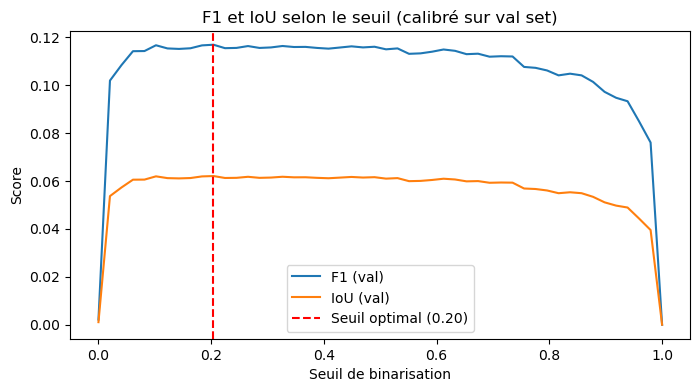

In [18]:
def compute_metrics(preds_prob, targets, threshold=0.5):
    preds = (preds_prob >= threshold).astype(float)

    TP = ((preds == 1) & (targets == 1)).sum()
    FP = ((preds == 1) & (targets == 0)).sum()
    FN = ((preds == 0) & (targets == 1)).sum()
    TN = ((preds == 0) & (targets == 0)).sum()

    precision = TP / (TP + FP + 1e-8)
    recall    = TP / (TP + FN + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)
    iou       = TP / (TP + FP + FN + 1e-8)
    accuracy  = (TP + TN) / (TP + FP + FN + TN + 1e-8)

    return {"Accuracy": accuracy, "Précision": precision, "Rappel": recall, "F1": f1, "IoU": iou}

# --- Calibration du seuil sur le VAL set (évite le data leakage) ---
thresholds    = np.linspace(0, 1, 50)
val_f1_scores = [compute_metrics(val_preds_all, val_targets_all, t)["F1"]  for t in thresholds]
val_iou_scores= [compute_metrics(val_preds_all, val_targets_all, t)["IoU"] for t in thresholds]

best_t = thresholds[np.argmax(val_f1_scores)]
print(f"Seuil optimal (calibré sur val set) : {best_t:.2f}  →  F1_val = {max(val_f1_scores):.4f}")

# --- Évaluation finale sur le TEST set avec le seuil calibré ---
metrics = compute_metrics(all_preds, all_targets, threshold=best_t)
print("\n=== Métriques sur le test set (seuil calibré sur val set) ===")
for name, val in metrics.items():
    print(f"  {name:<12}: {val:.4f}")

# Courbe F1 et IoU sur le val set
plt.figure(figsize=(8, 4))
plt.plot(thresholds, val_f1_scores,  label="F1 (val)")
plt.plot(thresholds, val_iou_scores, label="IoU (val)")
plt.axvline(x=best_t, color='red', linestyle='--', label=f"Seuil optimal ({best_t:.2f})")
plt.xlabel("Seuil de binarisation")
plt.ylabel("Score")
plt.title("F1 et IoU selon le seuil (calibré sur val set)")
plt.legend()
plt.show()

## Post-traitement morphologique (Option 3)

L'érosion morphologique **réduit les faux positifs** en supprimant les prédictions isolées.
Principe : un pixel prédit à 1 n'est conservé que si ses voisins immédiats sont aussi à 1.
Ça élimine le "bruit" de pixels positifs éparpillés tout en préservant les régions cohérentes.

- `iterations=1` : érosion légère (supprime les pixels isolés)
- `iterations=2` : érosion forte (ne conserve que les zones compactes)


=== Comparaison sans / avec érosion morphologique (test set) ===

Métrique       Sans érosion     Érosion ×1     Érosion ×2
--------------------------------------------------------
Accuracy             0.9962         0.9984         0.9988
Précision            0.0786         0.1146         0.1529
Rappel               0.2368         0.0650         0.0267
F1                   0.1180         0.0830         0.0455
IoU                  0.0627         0.0433         0.0233
--------------------------------------------------------
(seuil : 0.20 pour sans-érosion, 0.5 appliqué sur binaire érodé)

--- Exemple visuel : effet de l'érosion sur une prédiction ---


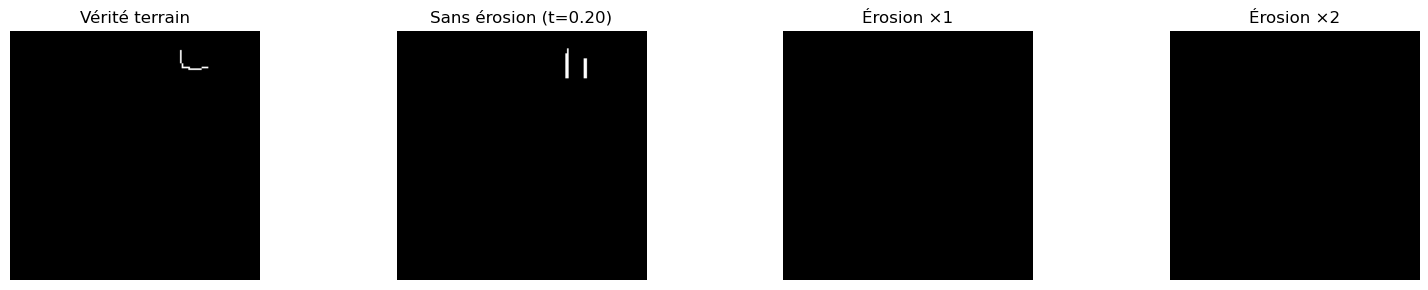

In [19]:
def erode_batch(probs_flat, targets_flat, img_shape, threshold, iterations=1):
    """
    Applique l'érosion image par image puis recalcule les métriques.
    probs_flat   : (N_pixels,) — probabilités aplaties
    targets_flat : (N_pixels,) — vérités terrain aplaties
    img_shape    : (H, W) de chaque image (ex. (150, 150))
    """
    n_pixels = img_shape[0] * img_shape[1]
    n_imgs   = len(probs_flat) // n_pixels

    eroded_preds = []
    for k in range(n_imgs):
        pred_2d = (probs_flat[k*n_pixels:(k+1)*n_pixels] >= threshold).reshape(img_shape)
        pred_eroded = binary_erosion(pred_2d, iterations=iterations).astype(float)
        eroded_preds.append(pred_eroded.flatten())

    eroded_flat = np.concatenate(eroded_preds)
    return eroded_flat


IMG_SHAPE = (150, 150)

print("=== Comparaison sans / avec érosion morphologique (test set) ===\n")
print(f"{'Métrique':<12} {'Sans érosion':>14} {'Érosion ×1':>14} {'Érosion ×2':>14}")
print("-" * 56)

for metric in ["Accuracy", "Précision", "Rappel", "F1", "IoU"]:
    m0 = compute_metrics(all_preds, all_targets, best_t)[metric]
    eroded1 = erode_batch(all_preds, all_targets, IMG_SHAPE, best_t, iterations=1)
    m1 = compute_metrics(eroded1,   all_targets, threshold=0.5)[metric]
    eroded2 = erode_batch(all_preds, all_targets, IMG_SHAPE, best_t, iterations=2)
    m2 = compute_metrics(eroded2,   all_targets, threshold=0.5)[metric]
    print(f"{metric:<12} {m0:>14.4f} {m1:>14.4f} {m2:>14.4f}")

print("-" * 56)
print(f"(seuil : {best_t:.2f} pour sans-érosion, 0.5 appliqué sur binaire érodé)")

# Visualisation d'un exemple : avant / après érosion
print("\n--- Exemple visuel : effet de l'érosion sur une prédiction ---")
sample_prob = all_preds[:IMG_SHAPE[0]*IMG_SHAPE[1]].reshape(IMG_SHAPE)
sample_bin  = (sample_prob >= best_t).astype(float)
sample_e1   = binary_erosion(sample_bin, iterations=1).astype(float)
sample_e2   = binary_erosion(sample_bin, iterations=2).astype(float)
sample_gt   = all_targets[:IMG_SHAPE[0]*IMG_SHAPE[1]].reshape(IMG_SHAPE)

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for ax, img, title in zip(axes,
    [sample_gt, sample_bin, sample_e1, sample_e2],
    ["Vérité terrain", f"Sans érosion (t={best_t:.2f})", "Érosion ×1", "Érosion ×2"]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 11c) Visualisation côte à côte avec superposition des erreurs

Rouge = faux positifs (prédit 1, réel 0) | Bleu = faux négatifs (prédit 0, réel 1)

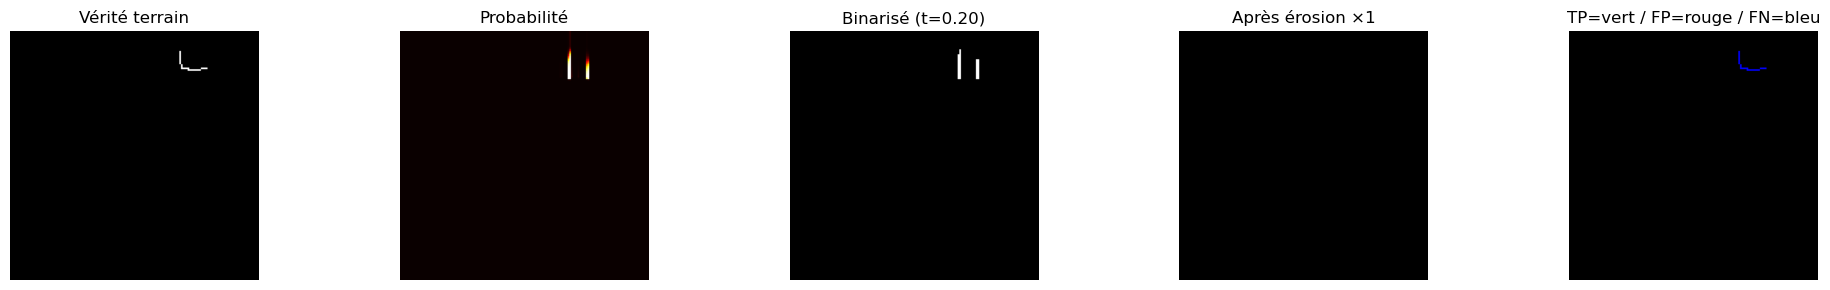

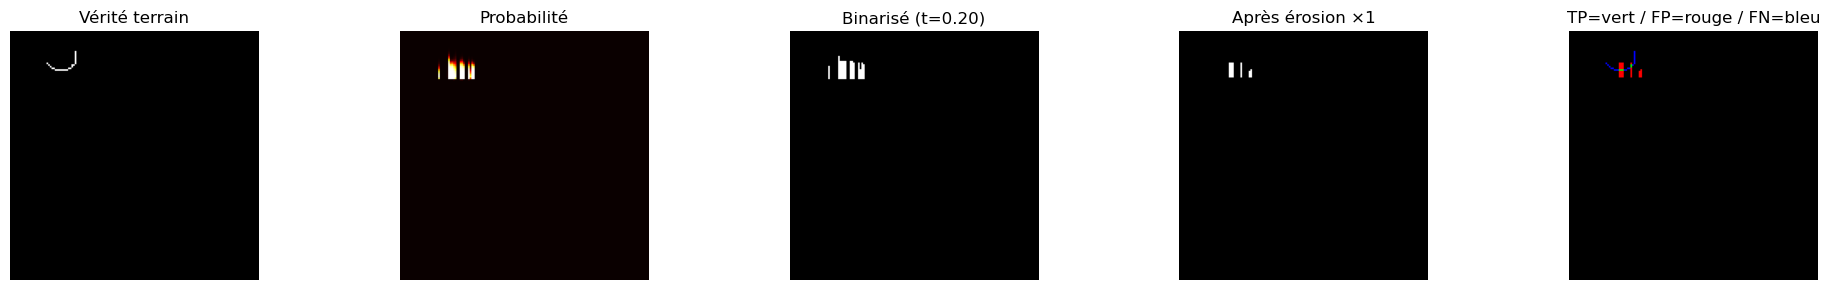

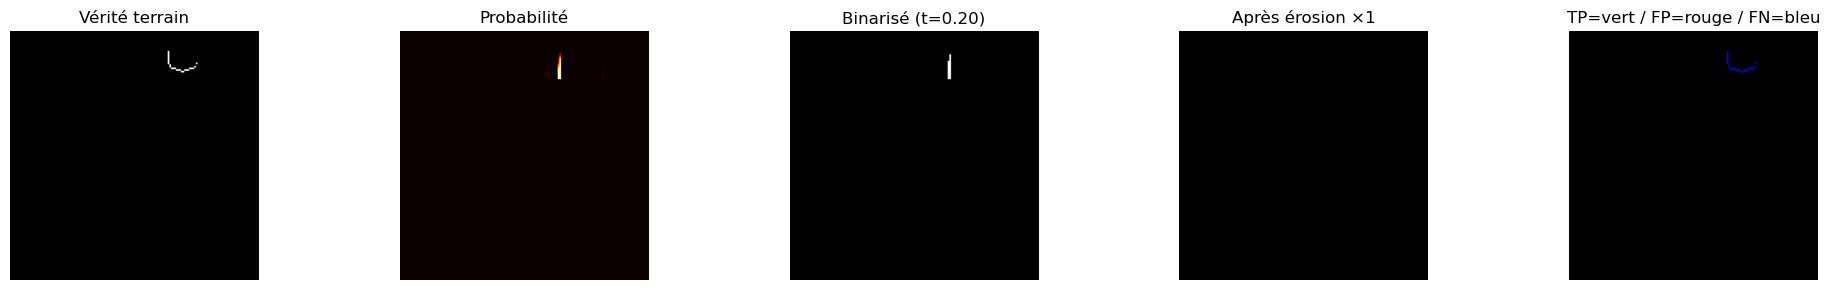

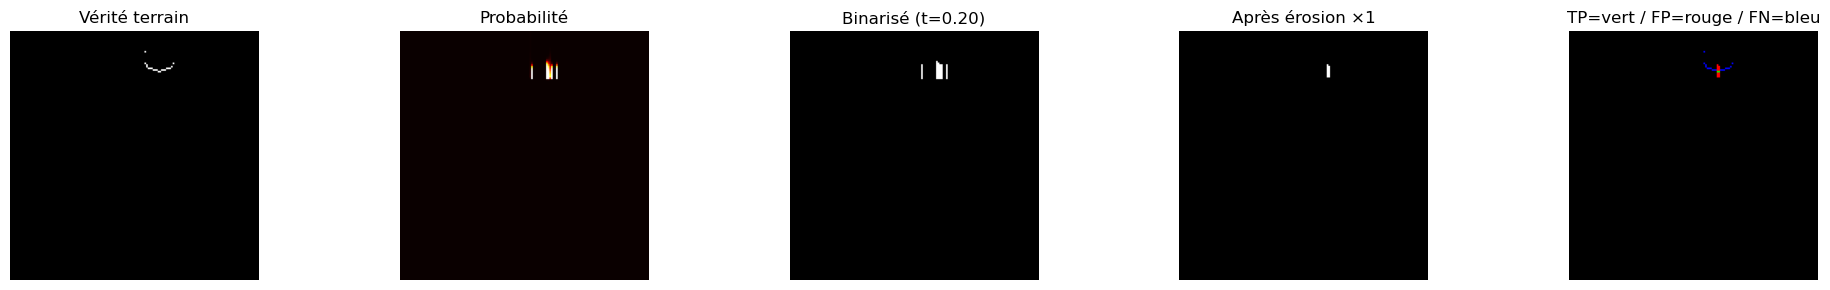

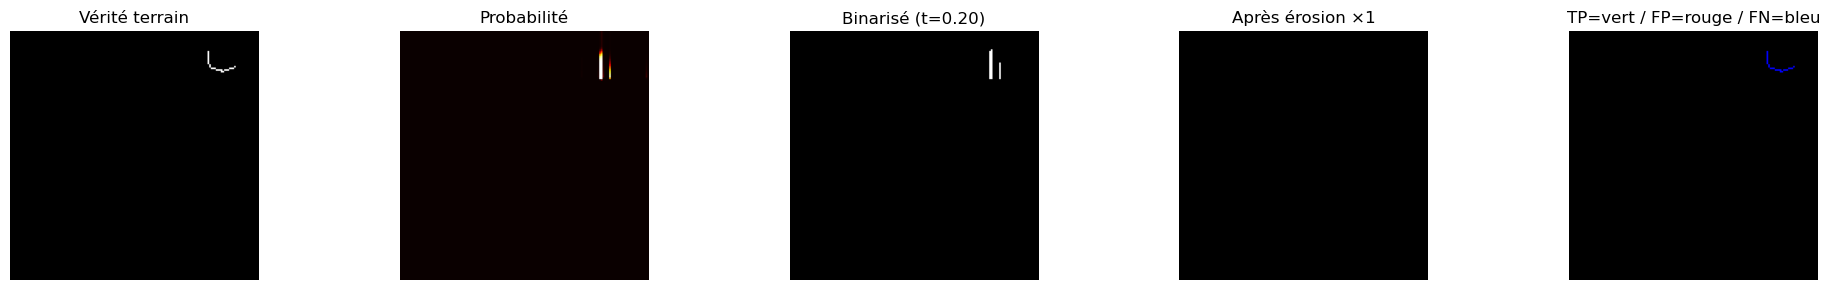

In [20]:
def show_diagnostic(model, loader, device, num_samples=5, threshold=0.5, erosion_iter=1):
    """
    Affiche 5 colonnes : vérité terrain / probabilité / binarisé / érodé / carte d'erreurs.
    erosion_iter : nombre d'itérations d'érosion (0 = désactivé)
    """
    model.eval()
    shown = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = torch.sigmoid(model(inputs))

            for i in range(inputs.size(0)):
                pred_prob = outputs[i].squeeze().cpu().numpy()
                pred_bin  = (pred_prob >= threshold).astype(float)
                pred_post = binary_erosion(pred_bin, iterations=erosion_iter).astype(float) \
                            if erosion_iter > 0 else pred_bin
                target    = targets[i].squeeze().cpu().numpy()

                # Carte d'erreurs sur la prédiction post-traitée
                error_map = np.zeros((*target.shape, 3))
                error_map[(pred_post == 1) & (target == 1)] = [0, 1, 0]   # TP vert
                error_map[(pred_post == 1) & (target == 0)] = [1, 0, 0]   # FP rouge
                error_map[(pred_post == 0) & (target == 1)] = [0, 0, 1]   # FN bleu

                fig, axes = plt.subplots(1, 5, figsize=(20, 3))
                axes[0].imshow(target,    cmap="gray", vmin=0, vmax=1)
                axes[0].set_title("Vérité terrain")
                axes[1].imshow(pred_prob, cmap="hot",  vmin=0, vmax=1)
                axes[1].set_title("Probabilité")
                axes[2].imshow(pred_bin,  cmap="gray", vmin=0, vmax=1)
                axes[2].set_title(f"Binarisé (t={threshold:.2f})")
                axes[3].imshow(pred_post, cmap="gray", vmin=0, vmax=1)
                axes[3].set_title(f"Après érosion ×{erosion_iter}")
                axes[4].imshow(error_map)
                axes[4].set_title("TP=vert / FP=rouge / FN=bleu")
                for ax in axes:
                    ax.axis("off")
                plt.tight_layout()
                plt.show()

                shown += 1
                if shown >= num_samples:
                    return

show_diagnostic(model, test_loader, device, num_samples=5, threshold=best_t, erosion_iter=1)

## 12) Pipeline en cascade : UNet1D → Y-Net

Le Y-Net prend **deux entrées** :
- Les signaux bruts `(9, 801)` — Encodeur I
- La prédiction grossière du UNet1D `(1, 150, 150)` — Encodeur II

Le UNet1D est d'abord entraîné seul (étape précédente),
puis ses poids sont **figés** pendant l'entraînement du Y-Net.
Le Y-Net apprend uniquement à **affiner** la sortie du premier réseau.

```
Signaux (9,801) ──────────────────────────────────► Encodeur I ──┐
                 └──► UNet1D (figé) ──► carte grossière ──► Encodeur II ──┤
                                                                  └──► Décodeur ──► carte affinée
```


In [21]:
class DoubleConv1D(nn.Module):
    def __init__(self, in_ch, out_ch, k=5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, k, padding=k//2, bias=False),
            nn.BatchNorm1d(out_ch), nn.ReLU(inplace=True),
            nn.Conv1d(out_ch, out_ch, k, padding=k//2, bias=False),
            nn.BatchNorm1d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class DoubleConv2D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class YNetCascade(nn.Module):
    """
    Y-Net prenant en entrée :
      - x_sig : signaux bruts (B, 8, 2056)
      - x_coarse : prédiction grossière du UNet1D (B, 1, 150, 150)
    Retourne des logits (B, 1, 150, 150).
    """
    def __init__(self):
        super().__init__()

        # ── Encodeur I : signaux bruts 1D ─────────────────────────────────
        self.e1_1 = DoubleConv1D(8,  32)
        self.e1_2 = DoubleConv1D(32, 64)
        self.e1_3 = DoubleConv1D(64, 128)
        self.pool1 = nn.MaxPool1d(2)

        # ── Encodeur II : carte grossière 2D ──────────────────────────────
        self.e2_1 = DoubleConv2D(1,  32)
        self.e2_2 = DoubleConv2D(32, 64)
        self.e2_3 = DoubleConv2D(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        # ── Décodeur partagé ──────────────────────────────────────────────
        # Chaque étage : upsample + skip enc2 + skip enc1 projeté en 2D
        self.up3  = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec3 = DoubleConv2D(64 + 64 + 64, 64)

        self.up2  = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec2 = DoubleConv2D(32 + 32 + 32, 32)

        self.up1  = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.dec1 = DoubleConv2D(16, 16)

        self.final = nn.Conv2d(16, 1, kernel_size=1)

    def _1d_to_2d(self, feat_1d, h, w):
        """Projette un skip 1D (B, C, L) en feature map 2D (B, C, H, W)."""
        # On broadcast sur la hauteur puis on interpole à la bonne taille
        x = feat_1d.unsqueeze(2).expand(-1, -1, h, -1)   # (B, C, H, L)
        return F.interpolate(x, size=(h, w), mode='bilinear', align_corners=False)

    def forward(self, x_sig, x_coarse):
        # ── Encodeur I ────────────────────────────────────────────────────
        s1_1 = self.e1_1(x_sig)                   # (B, 32,  801)
        s1_2 = self.e1_2(self.pool1(s1_1))        # (B, 64,  400)
        s1_3 = self.e1_3(self.pool1(s1_2))        # (B, 128, 200)

        # ── Encodeur II ───────────────────────────────────────────────────
        s2_1 = self.e2_1(x_coarse)                # (B, 32,  150, 150)
        s2_2 = self.e2_2(self.pool2(s2_1))        # (B, 64,   75,  75)
        s2_3 = self.e2_3(self.pool2(s2_2))        # (B, 128,  37,  37)

        # Goulot : on part de s2_3 (le plus compressé de l'enc II)
        d = self.up3(s2_3)                         # (B, 64, 75, 75)
        sk2 = F.interpolate(s2_2, d.shape[2:], mode='bilinear', align_corners=False)
        sk1 = self._1d_to_2d(s1_2, d.shape[2], d.shape[3])
        d = self.dec3(torch.cat([d, sk2, sk1], dim=1))

        d = self.up2(d)                            # (B, 32, 150, 150)
        sk2 = F.interpolate(s2_1, d.shape[2:], mode='bilinear', align_corners=False)
        sk1 = self._1d_to_2d(s1_1, d.shape[2], d.shape[3])
        d = self.dec2(torch.cat([d, sk2, sk1], dim=1))

        d = self.up1(d)
        d = self.dec1(d)
        out = self.final(d)
        return F.interpolate(out, size=(150, 150), mode='bilinear', align_corners=False)


# Vérification des shapes
with torch.no_grad():
    _sig    = torch.zeros(2, 8, 801)
    _coarse = torch.zeros(2, 1, 150, 150)
    print('YNetCascade output shape :', YNetCascade()(_sig, _coarse).shape)


YNetCascade output shape : torch.Size([2, 1, 150, 150])


### 18b) Dataset cascade

Le dataset cascade génère à la volée la prédiction grossière
du UNet1D (figé) pour alimenter l'Encodeur II du Y-Net.


In [22]:
full_dataset = SignalToImageDataset(X, y, augment=False)
# Split 65/15/20 adapté aux ~380 échantillons disponibles
n = len(full_dataset)
n_train = int(0.65 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val
lengths = [n_train, n_val, n_test]
train_set, val_set, test_set = random_split(full_dataset, lengths)
# Dataset d'entraînement avec augmentation
train_dataset_aug = SignalToImageDataset(
        X[list(train_set.indices)],
        y[list(train_set.indices)],
        augment=True
)

In [23]:
class CascadeDataset(Dataset):
    """
    Dataset pour le Y-Net cascade.
    Utilise la reconstruction physique réelle (sub[1] du .mat)
    comme Encodeur II — plus besoin de la générer depuis le UNet1D.

    Retourne des triplets (x_sig, x_bf, y) :
      x_sig : signaux bruts    (8, 2056)
      x_bf  : recons. physique (1, 150, 150)
      y     : carte cible      (1, 150, 150)
    """
    def __init__(self, base_dataset, unet_model, device):
        self.ds     = base_dataset
        self.model  = unet_model.eval()
        self.device = device

    def __len__(self): return len(self.ds)

    def __getitem__(self, idx):
        x, y = self.ds[idx]
        with torch.no_grad():
            x_pred = torch.sigmoid(
                self.model(x.unsqueeze(0).to(self.device))
            ).squeeze(0).cpu()   # (1, 150, 150)
        return x, x_pred, y


# Loaders cascade — utilisent la reconstruction physique réelle
casc_train_loader = DataLoader(
    CascadeDataset(train_dataset_aug,model_unet, device), batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)
casc_val_loader = DataLoader(
    CascadeDataset(val_set,model_unet, device), batch_size=BATCH_SIZE, shuffle=False
)
casc_test_loader = DataLoader(
    CascadeDataset(test_set,model_unet, device), batch_size=BATCH_SIZE, shuffle=False
)
print('Loaders cascade créés (reconstruction physique réelle).')

# On n'a plus besoin de figer le UNet1D — le Y-Net utilise sub[1] directement
print('Note : le Y-Net utilise la reconstruction physique du fichier .mat')
print('       (sub[1]) comme second encodeur — aucun modèle à figer.')


Loaders cascade créés (reconstruction physique réelle).
Note : le Y-Net utilise la reconstruction physique du fichier .mat
       (sub[1]) comme second encodeur — aucun modèle à figer.


In [25]:
for x, x_pred, y in casc_train_loader :
    print(x.squeeze(1).size(), y.size(), x_pred.size())
    outputs = torch.sigmoid(model(x.to(device)))
    print(outputs.size())
    print(x_pred.size())
    print(x_pred.squeeze(1).size())
    break

torch.Size([8, 8, 2056]) torch.Size([8, 1, 150, 150]) torch.Size([8, 1, 150, 150])
torch.Size([8, 1, 150, 150])
torch.Size([8, 1, 150, 150])
torch.Size([8, 150, 150])


### 18c) Entraînement du Y-Net

La boucle d'entraînement est légèrement modifiée pour gérer
les **deux entrées** du Y-Net `(x_sig, x_coarse)`.


In [ ]:
def train_ynet(model, train_loader, val_loader, criterion, device,
               epochs=300, lr=5e-4, patience=40, model_name='ynet'):
    """
    Boucle d'entraînement pour le Y-Net en cascade.
    Les loaders fournissent des triplets (x_sig, x_coarse, y).
    """
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=20
    )
    best_val   = float('inf')
    best_w     = copy.deepcopy(model.state_dict())
    no_improve = 0
    history    = {'train': [], 'val': []}
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for x_sig, x_coarse, y in train_loader:
            x_sig, x_coarse, y = x_sig.to(device), x_coarse.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x_sig.squeeze(1), x_coarse), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_sig, x_coarse, y in val_loader:
                x_sig, x_coarse, y = x_sig.to(device), x_coarse.to(device), y.to(device)
                val_loss += criterion(model(x_sig.squeeze(1),x_coarse), y).item()
        val_loss /= len(val_loader)

        history['train'].append(train_loss)
        history['val'].append(val_loss)
        scheduler.step(val_loss)

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f'[{model_name}] Epoch {epoch+1:3d}/{epochs}  '
                  f'train={train_loss:.4f}  val={val_loss:.4f}')

        if val_loss < best_val - 1e-5:
            best_val = val_loss
            best_w   = copy.deepcopy(model.state_dict())
            torch.save(best_w, f'{model_name}.pth')
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'Early stopping à l\'epoch {epoch+1}')
                break

    model.load_state_dict(best_w)
    print(f'\n[{model_name}] Meilleure val_loss : {best_val:.4f}')
    return model, history


print('='*50)
print('Entraînement Y-Net cascade')
print('='*50)
criterion = FocalDiceLoss(alpha=0.75, gamma=2.0, dice_weight=0.5)
model_ynet, history_ynet = train_ynet(
    YNetCascade(), casc_train_loader, casc_val_loader, criterion, device,
    epochs=300, lr=5e-4, patience=40, model_name='model_ynet_cascade'
)


Entraînement Y-Net cascade
[model_ynet_cascade] Epoch   1/300  train=0.5112  val=0.5171


In [ ]:
def load_model(model_class, path, device):
    model = model_class().to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    print(f"Modèle chargé depuis {path}")
    return model
model_ynet = load_model(YNetCascade, "model_ynet_cascade.pth", device)

### 18d) Évaluation du Y-Net cascade


In [ ]:
def collect_preds_ynet(model, loader, device):
    """Collecte prédictions pour le Y-Net (triplets en entrée)."""
    model.eval()
    all_probs, all_targets = [], []
    with torch.no_grad():
        for x_sig, x_coarse, y in loader:
            x_sig, x_coarse = x_sig.to(device), x_coarse.to(device)
            probs = torch.sigmoid(model(x_sig, x_coarse)).cpu().numpy()
            all_probs.append(probs.flatten())
            all_targets.append(y.numpy().flatten())
    return np.concatenate(all_probs), np.concatenate(all_targets)


def show_cascade_comparison(model_base, model_ynet, loader_base,
                             loader_casc, device, num_samples=6,
                             threshold=0.5):
    """Affiche GT / UNet1D grossier / Y-Net affiné côte à côte."""
    model_base.eval()
    model_ynet.eval()
    shown = 0
    fig, axes = plt.subplots(num_samples, 3, figsize=(10, num_samples * 2))

    base_iter = iter(loader_base)
    casc_iter = iter(loader_casc)

    while shown < num_samples:
        x_base, y_base = next(base_iter)
        x_sig, x_coarse, y_casc = next(casc_iter)

        with torch.no_grad():
            prob_base = torch.sigmoid(
                model_base(x_base.to(device))).cpu().numpy()
            prob_ynet = torch.sigmoid(
                model_ynet(x_sig.to(device), x_coarse.to(device))).cpu().numpy()

        for i in range(x_base.size(0)):
            if shown >= num_samples:
                break
            axes[shown, 0].imshow(y_base[i].squeeze(), cmap='gray', vmin=0, vmax=1)
            axes[shown, 0].set_title('Vérité terrain', fontsize=8)
            axes[shown, 0].axis('off')

            axes[shown, 1].imshow(prob_base[i].squeeze(), cmap='gray', vmin=0, vmax=1)
            axes[shown, 1].set_title('UNet1D (grossier)', fontsize=8)
            axes[shown, 1].axis('off')

            axes[shown, 2].imshow(prob_ynet[i].squeeze(), cmap='gray', vmin=0, vmax=1)
            axes[shown, 2].set_title('Y-Net (affiné)', fontsize=8)
            axes[shown, 2].axis('off')
            shown += 1

    plt.suptitle('Comparaison UNet1D → Y-Net cascade', fontsize=11)
    plt.tight_layout()
    plt.show()


# Métriques Y-Net
probs_yn, targets_yn = collect_preds_ynet(model_ynet, casc_test_loader, device)
thresholds = np.linspace(0.05, 0.95, 60)
f1s_yn = [compute_metrics(probs_yn, targets_yn, t)['F1'] for t in thresholds]
best_t_yn = thresholds[np.argmax(f1s_yn)]
metrics_yn = compute_metrics(probs_yn, targets_yn, best_t_yn)

print(f'\nY-Net cascade — seuil optimal : {best_t_yn:.2f}')
for k, v in metrics_yn.items():
    print(f'  {k:<12}: {v:.4f}')

# Comparaison visuelle
show_cascade_comparison(
    model_unet, model_ynet,
    test_loader, casc_test_loader,
    device, num_samples=6, threshold=best_t_yn
)


In [ ]:
# Tableau comparatif : SimpleCNN / UNet1D / Y-Net cascade
print(f'{'Métrique':<14} {'U-Net':>12} {'Y-Net':>12}')
print('-' * 52)
for metric in ['Accuracy', 'Précision', 'Rappel', 'F1', 'IoU']:
    v_unet = results['U-Net']['metrics'][metric]
    v_yn   = metrics_yn[metric]
    best = max(v_unet, v_yn)
    mark_unet = '  ←' if v_unet == best else ''
    mark_yn   = '  ←' if v_yn   == best else ''
    print(f'{metric:<14} '
          f'{v_unet:>12.4f}{mark_unet:<4} {v_yn:>12.4f}{mark_yn}')
print('-' * 52)
#print(f'{'Seuil opt.':<14} {results["best_t"]:>12.2f} '
      #f'{results["U-Net"]["best_t"]:>12.2f} {best_t_yn:>12.2f}')


In [ ]:
def show_diagnostic_ynet(model, loader, device, num_samples=5,
                          threshold=0.5, title='Y-Net'):
    """
    Diagnostic complet pour le Y-Net cascade.
    Affiche pour chaque exemple 5 colonnes :
      1. Vérité terrain
      2. Reconstruction physique (BF) — entrée Encodeur II
      3. Carte de probabilité prédite
      4. Prédiction binarisée
      5. Carte d'erreurs (TP=vert / FP=rouge / FN=bleu)
    """
    model.eval()
    shown = 0

    with torch.no_grad():
        for x_sig, x_coarse, y in loader:
            x_sig_d   = x_sig.to(device)
            x_coarse_d = x_coarse.to(device)
            probs = torch.sigmoid(model(x_sig_d, x_coarse_d)).cpu().numpy()

            for i in range(x_sig.size(0)):
                if shown >= num_samples:
                    return

                prob   = probs[i].squeeze()                   # (150, 150)
                pred   = (prob >= threshold).astype(float)
                target = y[i].squeeze().numpy()               # (150, 150)
                bf     = x_coarse[i].squeeze().numpy()        # (150, 150)

                # Carte d'erreurs RGB
                err = np.zeros((*target.shape, 3))
                err[(pred==1) & (target==1)] = [0, 1, 0]     # TP vert
                err[(pred==1) & (target==0)] = [1, 0, 0]     # FP rouge
                err[(pred==0) & (target==1)] = [0, 0, 1]     # FN bleu

                # Métriques par image
                m = compute_metrics(prob.flatten(), target.flatten(), threshold)

                fig, axes = plt.subplots(1, 5, figsize=(20, 3))

                axes[0].imshow(target, cmap='gray', vmin=0, vmax=1)
                axes[0].set_title('Vérité terrain', fontsize=9)

                axes[1].imshow(bf, cmap='hot', vmin=0, vmax=1)
                axes[1].set_title('Recons. physique (BF)', fontsize=9)

                axes[2].imshow(prob, cmap='hot', vmin=0, vmax=1)
                axes[2].set_title('Probabilité Y-Net', fontsize=9)

                axes[3].imshow(pred, cmap='gray', vmin=0, vmax=1)
                axes[3].set_title(
                    f'Préd. (seuil={threshold:.2f})\n'
                    f'F1={m["F1"]:.3f}  IoU={m["IoU"]:.3f}',
                    fontsize=8
                )

                axes[4].imshow(err)
                axes[4].set_title(
                    f'TP=vert / FP=rouge / FN=bleu\n'
                    f'Rappel={m["Rappel"]:.3f}  Préc={m["Précision"]:.3f}',
                    fontsize=8
                )

                for ax in axes:
                    ax.axis('off')

                fig.suptitle(f'{title} — échantillon {shown+1}', fontsize=10)
                plt.tight_layout()
                plt.show()
                shown += 1

# ── Diagnostic Y-Net ─────────────────────────────────────────────────────────
print('\n─── Diagnostic Y-Net cascade ───')
show_diagnostic_ynet(
    model_ynet, casc_test_loader, device,
    num_samples=5, threshold=best_t_yn, title='Y-Net cascade'
)